**Graded Task 3**
---

----------

In [39]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

**Rectify the frame**
---

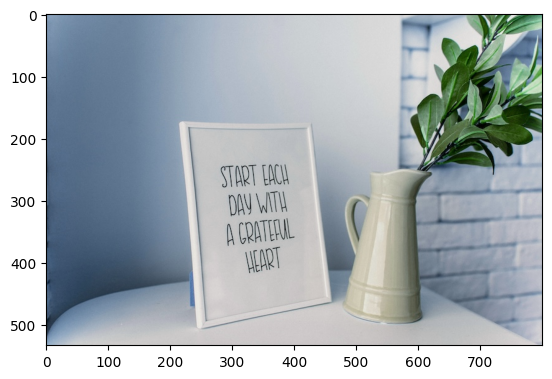

In [40]:
# Apply Homographic transformation to frame
image = cv2.imread('/content/frame.jpg')
plt.imshow(image)

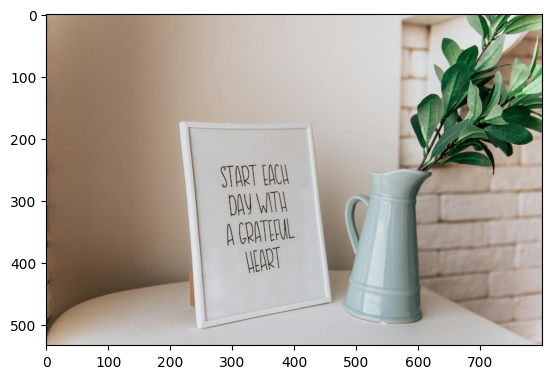

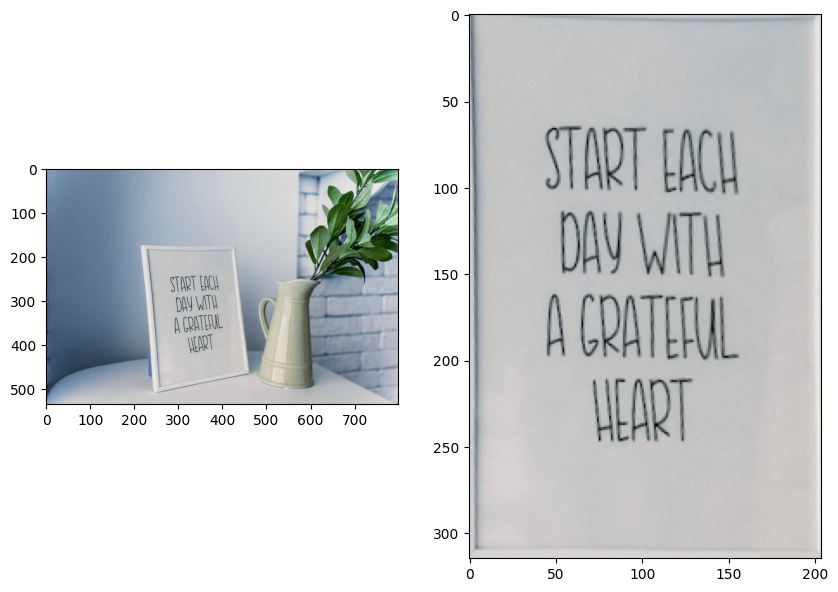

In [46]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

# pts = plt.ginput(4)
pts = [(229, 186), #top-left
       (424, 183),  #top-right
       (254, 501), #bottom-left
       (454, 459)]  #bottom-right

input_pts = np.array(pts, dtype=np.float32)

width = (np.linalg.norm(input_pts[0]-input_pts[1]), np.linalg.norm(input_pts[2]-input_pts[3]))
height = (np.linalg.norm(input_pts[0]-input_pts[2]), np.linalg.norm(input_pts[1]-input_pts[3]))
width = int(np.max(width))
height = int(np.max(height))

output_pts = np.array([(0, 0),
          (width-1, 0),
          (0, height-1),
          (width-1,height-1)], np.float32)

# compute the homography matrix
H = cv2.getPerspectiveTransform(input_pts, output_pts)

# Apply Transformation
output_image = cv2.warpPerspective(image, H, (width, height), flags=cv2.INTER_LINEAR)

# Display the original and transformed images
plt.figure(figsize = (10,8))
plt.subplot(121)
plt.imshow( image)
plt.subplot(122)
plt.imshow( output_image)

**Stitch the following two images together**
---

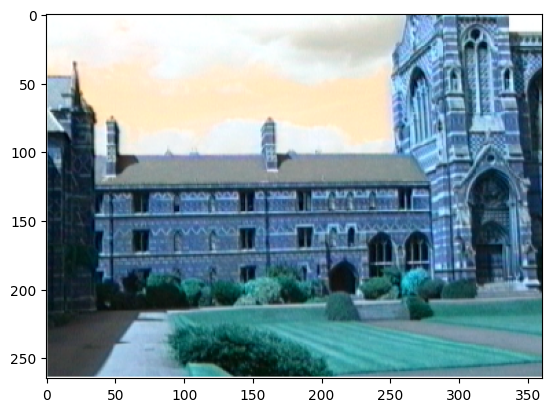

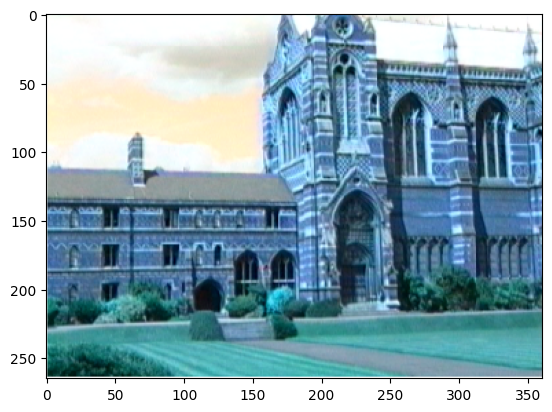

In [42]:
image1 = cv2.imread('/content/keble.000.png')
image2 = cv2.imread('/content/keble.003.png')
plt.imshow(image1)
plt.show()
plt.imshow(image2)

In [43]:
def stitch_img(image1, right, H):
    # Find the corners of the transformed image
    h1, w1 = image1.shape[:2]
    h2, w2 = image2.shape[:2]
    corners1 = np.array([[0, 0], [0, h1 - 1], [w1 - 1, h1 - 1], [w1 - 1, 0]], dtype=np.float32).reshape(-1, 1, 2)
    corners2 = np.array([[0, 0], [0, h2 - 1], [w2 - 1, h2- 1], [w2 - 1, 0]], dtype=np.float32).reshape(-1, 1, 2)

    transformed_corners = cv2.perspectiveTransform(corners1, H) # only corners 1 undergo transformation
    transformed_corners = np.concatenate((transformed_corners, corners2), axis=0)

    # Find the minimum and maximum coordinates to get the dimensions of the panoramic image
    min_x, min_y = np.int32(transformed_corners.min(axis=0).ravel())
    max_x, max_y = np.int32(transformed_corners.max(axis=0).ravel())

    # Adjust the homography matrix to account for the shift
    translation_matrix = np.array([[1, 0, -min_x], [0, 1, -min_y], [0, 0, 1]])
    adjusted_homography_matrix = np.dot(translation_matrix, H)

    # Apply the adjusted homography to warp the image
    stitched_image = cv2.warpPerspective(image1, adjusted_homography_matrix, (max_x - min_x + 1, max_y - min_y + 1))
    stitched_image[-min_y:image2.shape[0] - min_y, -min_x:image2.shape[1] - min_x,:] = image2

    return stitched_image

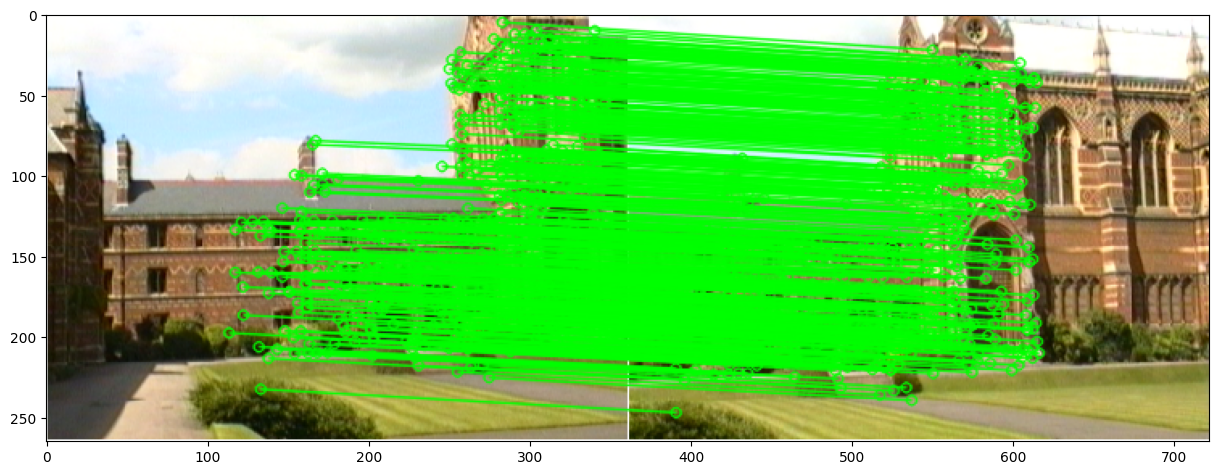

(<matplotlib.image.AxesImage at 0x7b472b0c0cd0>, None)

In [44]:
# Load the images
image1 = cv2.imread('/content/keble.000.png')
image2 = cv2.imread('/content/keble.003.png')

# Initialize the ORB detector
feat = cv2.SIFT_create()

# Find the keypoints and descriptors with ORB
kp1, des1 = feat.detectAndCompute(image1, None)
kp2, des2 = feat.detectAndCompute(image2, None)

# Create BFMatcher (Brute Force Matcher)
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1,des2, k=2)

# Apply ratio test
good = []
for m,n in matches:
    if m.distance < 0.75*n.distance:
        good.append(m)

# Extract the matched keypoints
src_pts = np.float32([ kp1[m.queryIdx].pt for m in good ]).reshape(-1,1,2)
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good ]).reshape(-1,1,2)

# Use RANSAC to estimate the homography matrix
H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, ransacReprojThreshold=5)

# Draw the matching
draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                   singlePointColor = None,
                   matchesMask = mask.ravel().tolist(), # draw only inliers
                   flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15,15))
output_image = cv2.drawMatches(image1,kp1,image2,kp2,good,None,**draw_params)
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB)), plt.show()

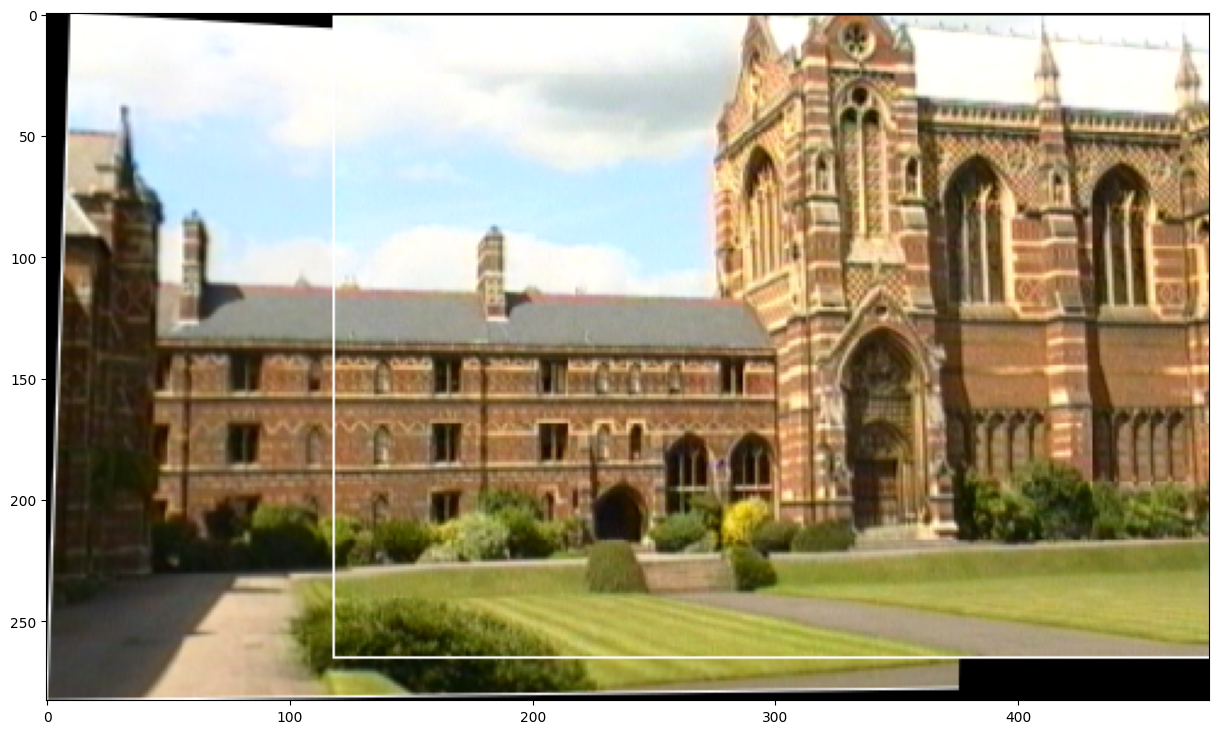

(<matplotlib.image.AxesImage at 0x7b47261bc970>, None)

In [45]:
stitch_image = stitch_img(image1, image2, H)
plt.figure(figsize=(15,15))
plt.imshow(cv2.cvtColor(stitch_image, cv2.COLOR_BGR2RGB)), plt.show()